# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [33]:
# Installing the libraries with the specified version.
!pip install numpy==1.26.2 pandas==2.2.2 matplotlib==3.8.0 seaborn==0.13.1 -q --user # <-- Increased numpy, pandas, and matplotlib versions to 1.26.2, 2.2.2, and 3.8.0, respectively, to avoid dependency issues

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [37]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [39]:
#from google.colab import drive
#drive.mount('/content/drive') # < I originally used Google Colab

# Display float numbers with three digits to the right of the decimal point.
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [41]:
# Write your code here to read the data
#df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/Projects/_project1/foodhub_order.csv') # < I originally used Google Colab
df = pd.read_csv('/Users/mvf327/Desktop/foodhub_order.csv')

In [43]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.750,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4,25,24


In [45]:
# last rows
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.310,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.180,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.220,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.180,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.450,Weekend,Not given,28,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [47]:
# Write your code here
print("There are", df.shape[0], 'rows and', df.shape[1],'columns in this dataset.')

There are 1898 rows and 9 columns in this dataset.


#### Observations:


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [49]:
# Write your code here
df.info();
print("-" * 15)
print("This data set includes these different data types:", df.dtypes.unique(), "where dtype O equals object.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB
---------------
This data set includes these different data types: [dtype('int64') dtype('O') dtype('float64')] where dtype O equals object.


#### Observations:


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [51]:
# Write your code here
df.isnull().sum() # No null values, but there are "not given" values from the rating column (from header info above)

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [53]:
df.duplicated().sum()
# No duplicated data

0

#### Observations:


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [55]:
# Write your code here
print(df.describe().T)
print("-" * 50)
print("The minimum, average, and maximum time it takes for food to be prepared once an order is placed are:", df['food_preparation_time'].min(), df['food_preparation_time'].mean(), 'and',df['food_preparation_time'].max(), "minutes.")

                         count        mean        std         min         25%  \
order_id              1898.000 1477495.500    548.050 1476547.000 1477021.250   
customer_id           1898.000  171168.478 113698.140    1311.000   77787.750   
cost_of_the_order     1898.000      16.499      7.484       4.470      12.080   
food_preparation_time 1898.000      27.372      4.632      20.000      23.000   
delivery_time         1898.000      24.162      4.973      15.000      20.000   

                              50%         75%         max  
order_id              1477495.500 1477969.750 1478444.000  
customer_id            128600.000  270525.000  405334.000  
cost_of_the_order          14.140      22.297      35.410  
food_preparation_time      27.000      31.000      35.000  
delivery_time              25.000      28.000      33.000  
--------------------------------------------------
The minimum, average, and maximum time it takes for food to be prepared once an order is placed are: 2

#### Observations:


### **Question 5:** How many orders are not rated? [1 mark]

In [57]:
# Write the code here
print("There are", df['rating'].value_counts().iloc[0], "orders with no rating.");

There are 736 orders with no rating.


#### Observations:


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

Unique order_id values:
 1898
----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------
Unique customer_id values:
 1200
----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


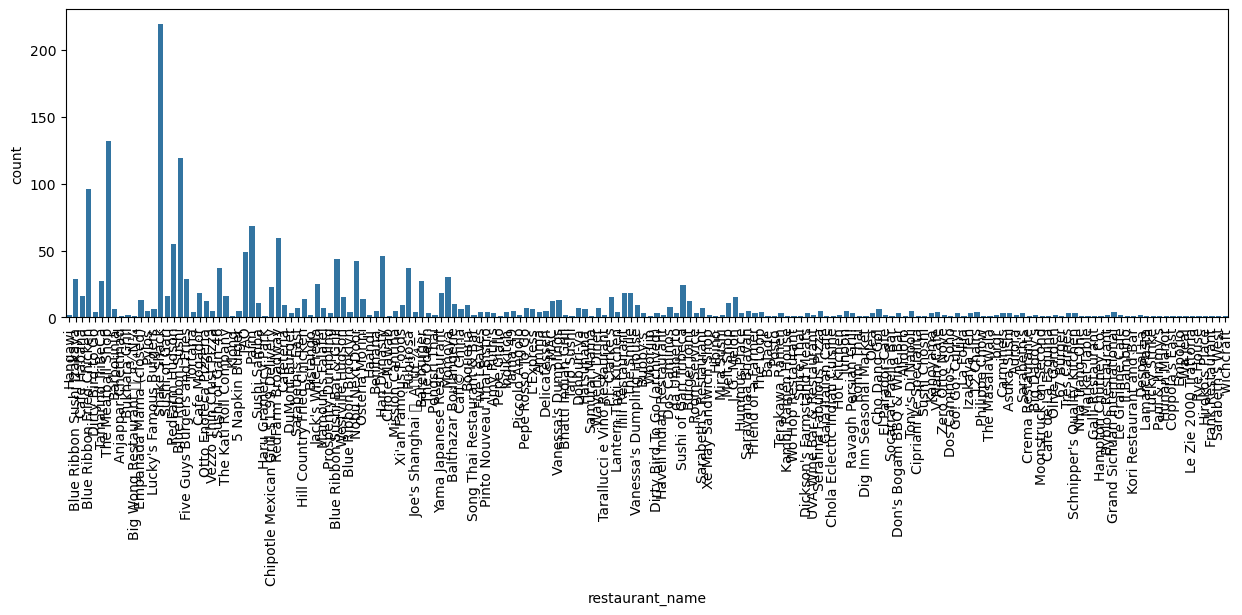

----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------


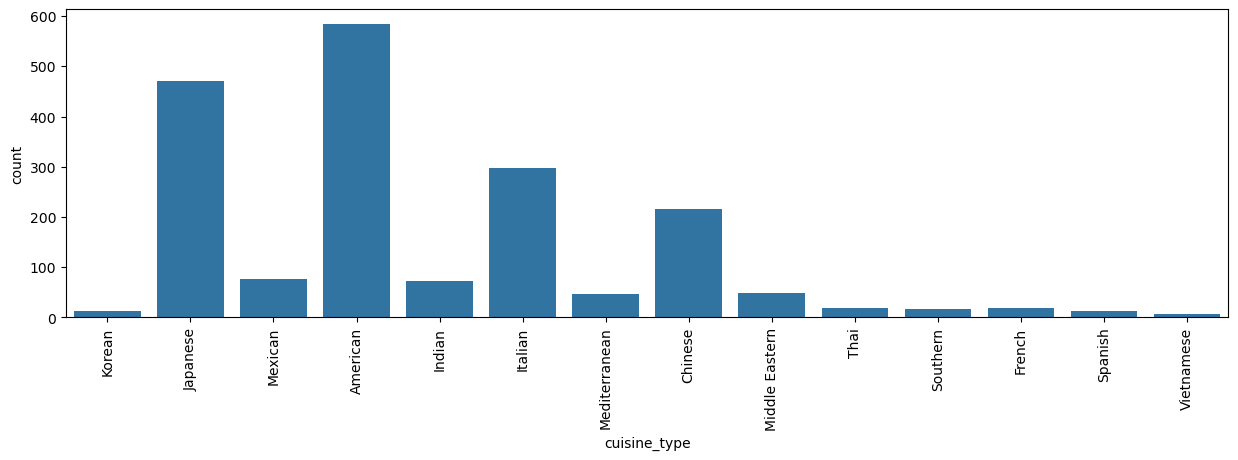

----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------
The mean and standard deviation of cost_of_the_order are 16 and 7.5 .


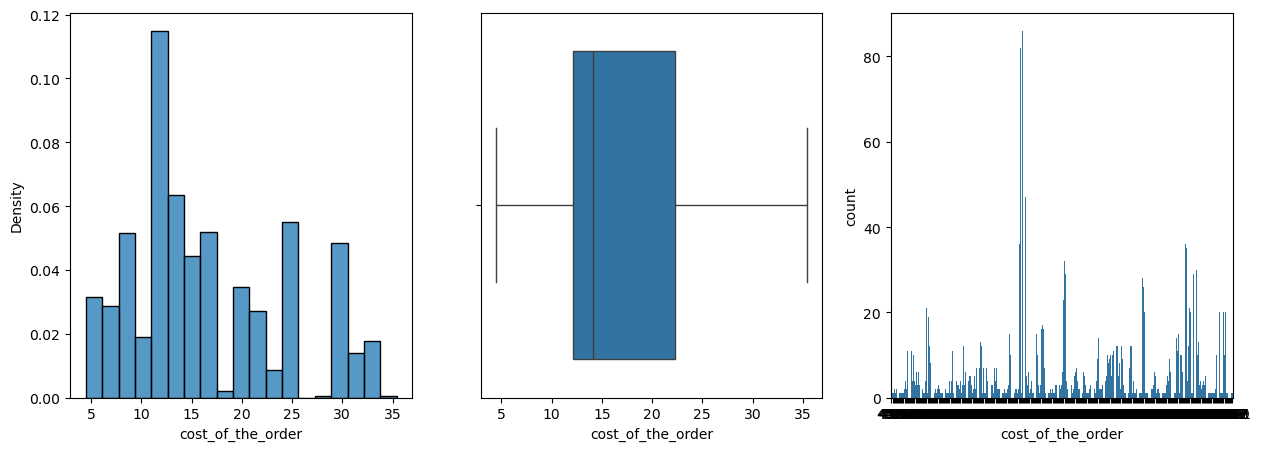

----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------


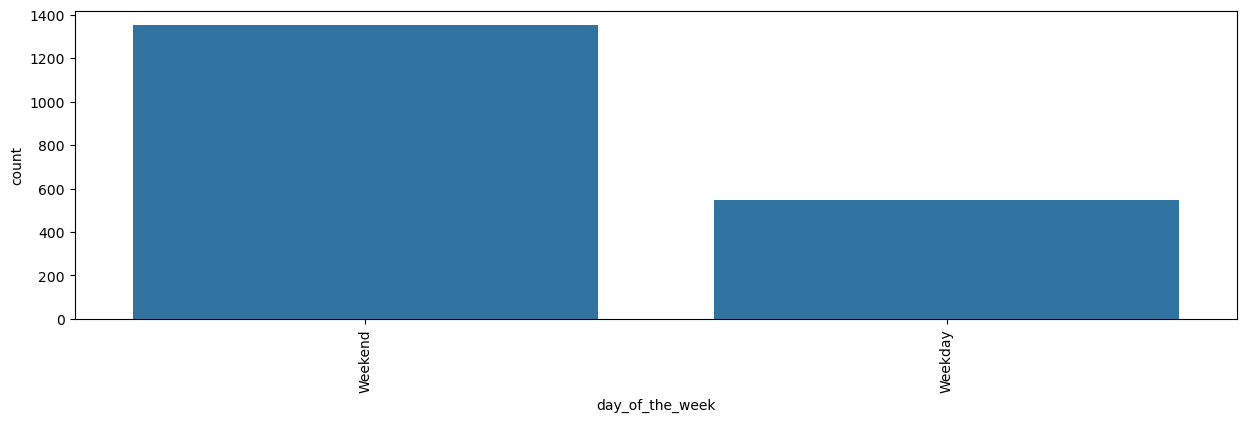

----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------


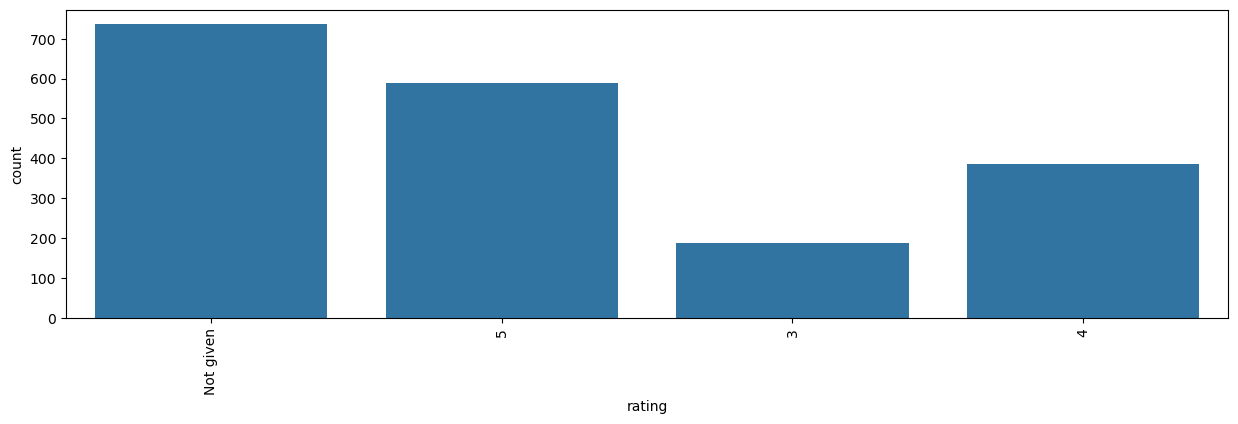

----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------
The mean and standard deviation of food_preparation_time are 27 and 4.6 .


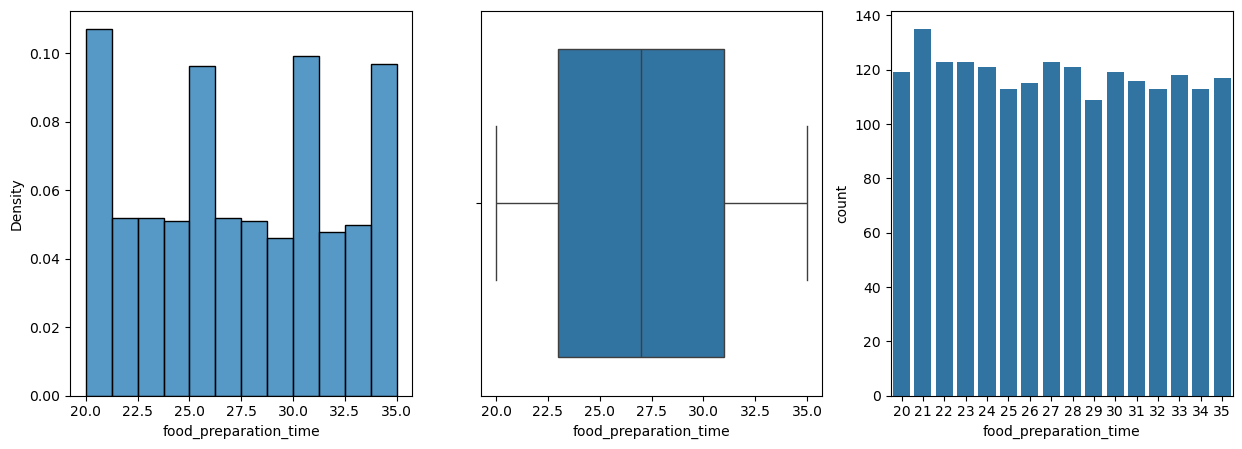

----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------
The mean and standard deviation of delivery_time are 24 and 5.0 .


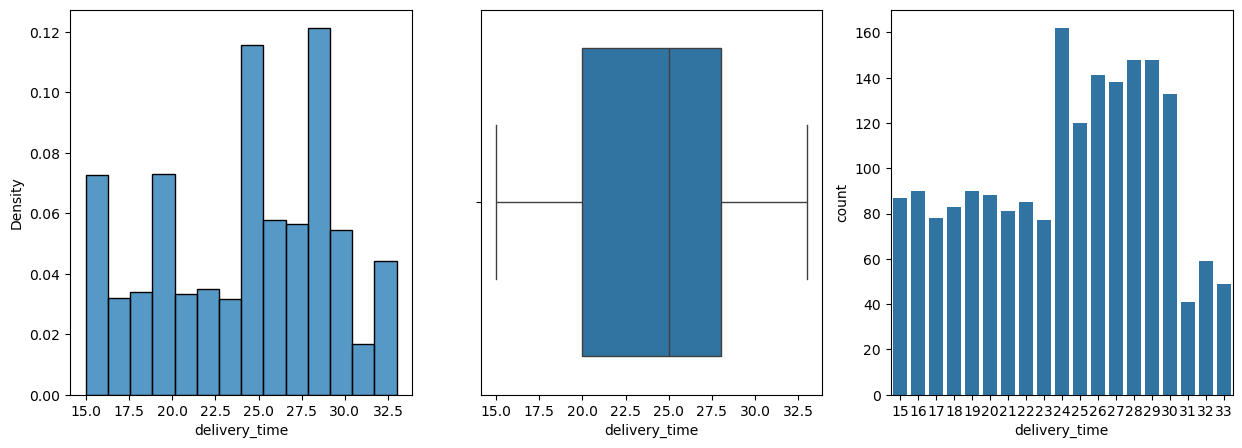

----------------------------------------------------------------------------------------------------
****************************************************************************************************
----------------------------------------------------------------------------------------------------


In [59]:
# Write the code here

# Number of columns in data
numb_cols = df.shape[1]

# Data types of all columns
dt = df.dtypes

for i in range(numb_cols): # For every column in the dataset
  # If the column is customer or order id print out the number of unique entries
  if df.iloc[:,i].name == 'customer_id' or df.iloc[:,i].name == 'order_id':
    print("Unique", df.iloc[:,i].name, "values:\n", df.iloc[:,i].nunique())
    print("-" * 100)
    print("*" * 100)
    print("-" * 100)
  # If the column is a categorical variable besides customer or order id (e.g., day_of_the_week) make a countplot of the data.
  elif dt.iloc[i] == 'object':
    # countplot
    plt.figure(figsize=(15,4))
    sns.countplot(data=df,x=df.loc[:,df.iloc[:,i].name]);
    plt.xticks(rotation=90)
    plt.show();
    print("-" * 100)
    print("*" * 100)
    print("-" * 100)
  else:
    # If the column consists of integer or float data then create a histogram, boxplot, and countplot side-by-side
    print("The mean and standard deviation of", df.iloc[:,i].name, "are", round(df.iloc[:,i].mean(),), "and", round(df.iloc[:,i].std(),1),".");
    # histogram
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    sns.histplot(data=df.loc[:,df.iloc[:,i].name],stat='density')
    # boxplot
    plt.subplot(1,3,2)
    sns.boxplot(data=df, x = df.loc[:,df.iloc[:,i].name])
    # countplot
    plt.subplot(1,3,3)
    sns.countplot(data=df,x=df.loc[:,df.iloc[:,i].name])
    plt.show();
    print("-" * 100)
    print("*" * 100)
    print("-" * 100)

# Observations
# 1. Only a few restaurants have over 100 orders
# 2. American and Japenese restaurants are most commonly ordered.
# 3. The variable "cost_of_order" does not appear to conform to a normal distribution and there are no outliers. The distribution appears to be right-skewed as many orders cost $10-15 and the average is around $16.
# 4. The variable "food_preparation_time" does not appear to conform to a normal distribution and there are no outliers. The most common food preparation times are 20, 25, 30, and just under 35 dollars, with the mean and stdev at 27 and 4.5, respectively.
# 5. The variable "delivery_time" does not appear to conform to a normal distribution and there are no outliers. Many delivery times are ~25 and 29 minutes, with the mean and stdev at 24 and 5, respectively.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [61]:
# Write the code here
print("The most orders come from these restaurants:")
top5 = df['restaurant_name'].value_counts().head(5)
for i in top5:
  res = df['restaurant_name'][i]
  print(res, "had", i, "orders.")


The most orders come from these restaurants:
Han Dynasty had 219 orders.
Otto Enoteca Pizzeria had 132 orders.
Momoya had 119 orders.
Blue Ribbon Fried Chicken had 96 orders.
Osteria Morini had 68 orders.


#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [63]:
# Write the code here
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(1)
print("The most popular cuisine on weekends is", df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().index[0],'.')

The most popular cuisine on weekends is American .


#### Observations:


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [65]:
# Write the code here

# Sum the number of orders over $20
Orders_over_20_dollars = df[df['cost_of_the_order'] > 20].value_counts().sum()

# Sum all orders
Total_orders = df['cost_of_the_order'].value_counts().sum()

# calculate the percent of orders that cost more than $20
percent_order_over_20 = round(Orders_over_20_dollars / Total_orders * 100, 2)
print(percent_order_over_20, "% of orders cost more than 20 dollars")

29.24 % of orders cost more than 20 dollars


#### Observations:


### **Question 10**: What is the mean order delivery time? [1 mark]

In [67]:
# Write the code here
print("The mean delivery time is", df['delivery_time'].mean().round(2), "minutes.")

The mean delivery time is 24.16 minutes.


#### Observations:


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [69]:
# Write the code here
top3 = df['customer_id'].value_counts().head(3)
print("Contratulations to the following customers who will receive a 20% discount voucher:")
for i in top3.index:
  print("Customer ID:", i, "placed", top3[i], "orders.")

Contratulations to the following customers who will receive a 20% discount voucher:
Customer ID: 52832 placed 13 orders.
Customer ID: 47440 placed 10 orders.
Customer ID: 83287 placed 9 orders.


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


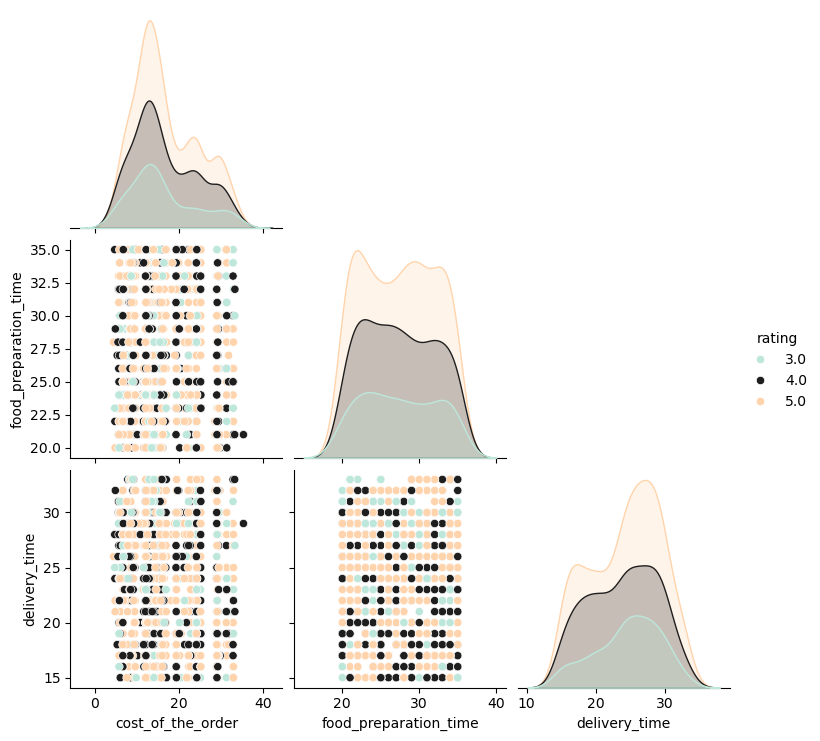

In [71]:
# Remove categorical variables to examine relationship between continuous ones
df_corr_data = df.drop(columns=['restaurant_name','cuisine_type','day_of_the_week','order_id','customer_id']).copy()

# Replacing missing values with nan
df_corr_data['rating'] = df_corr_data['rating'].replace(['Not given'],np.nan)

# changing the rating data type to float so that it can be regressed against other variables
df_corr_data['rating'] = df_corr_data['rating'].astype(float)

# Pair plot to examine relationship between continuous variables
sns.pairplot(data=df_corr_data, vars = ['cost_of_the_order','food_preparation_time','delivery_time'], hue='rating',palette = 'icefire',corner=True);

# There does not appear to be any association between:
# 1. Food prep time and cost of order
# 2. delivery time and cost of order
# 3. delivery time and food prep time

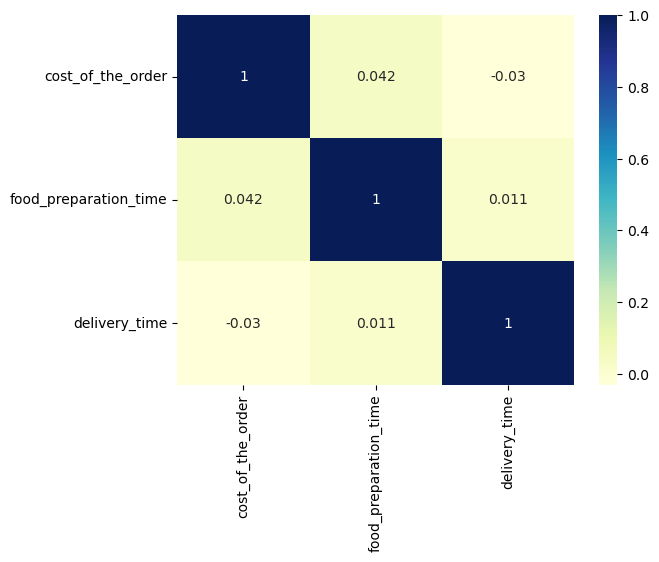

In [73]:
# Heat plot
sns.heatmap(data=df[['cost_of_the_order','food_preparation_time','delivery_time']].corr(), annot=True, cmap='YlGnBu');

# Recapulation of pair plot, but with correlation values

----------------------------------------------------------------------------------------------------


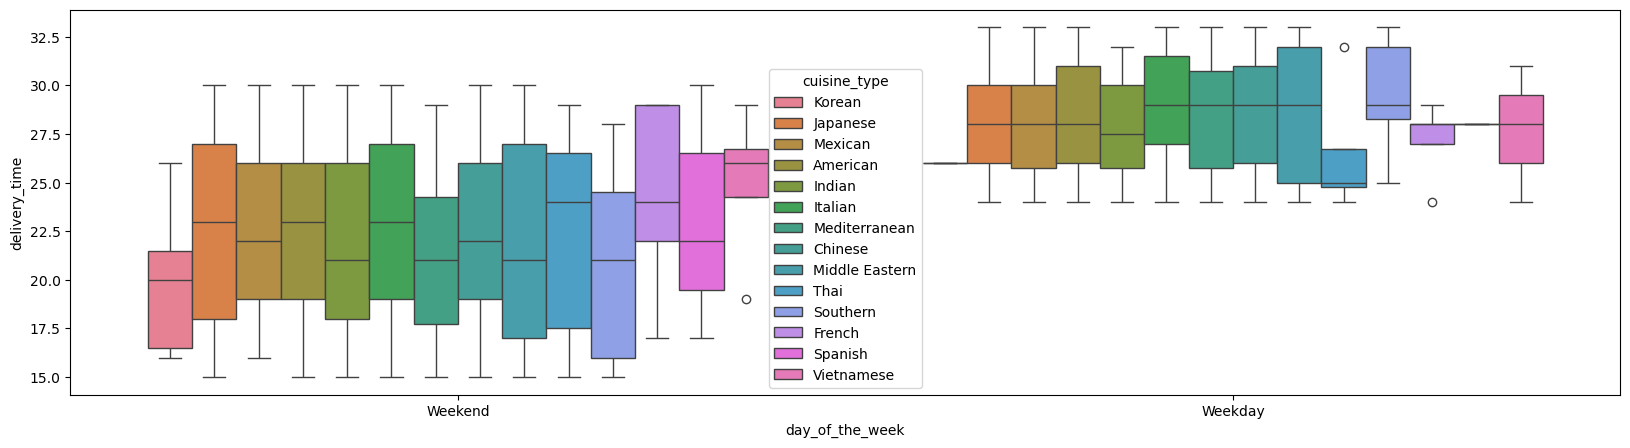

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------


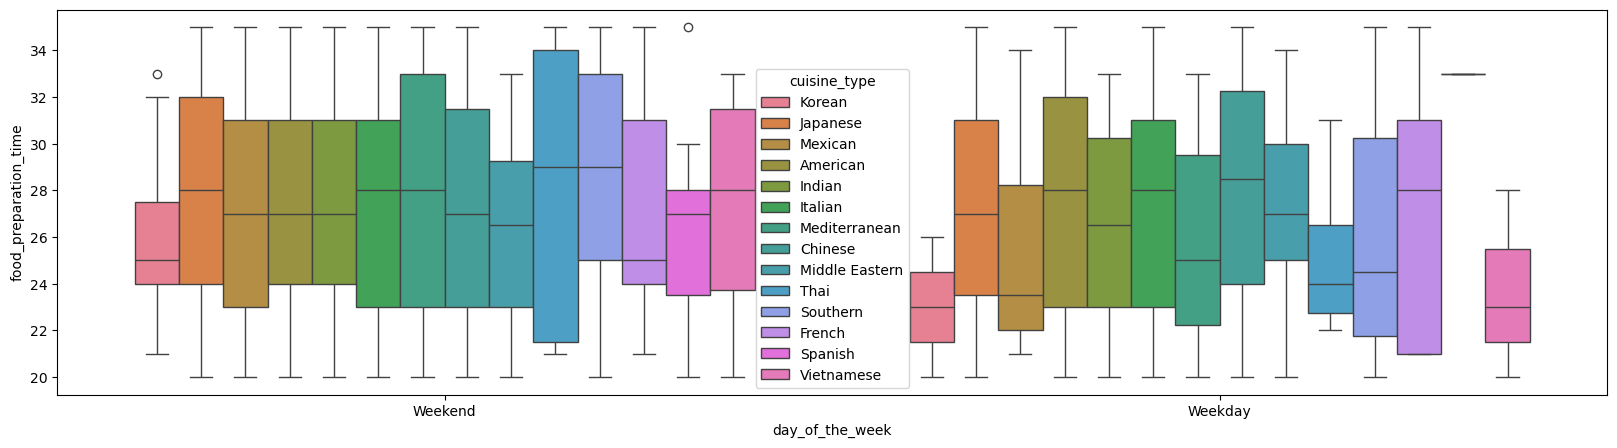

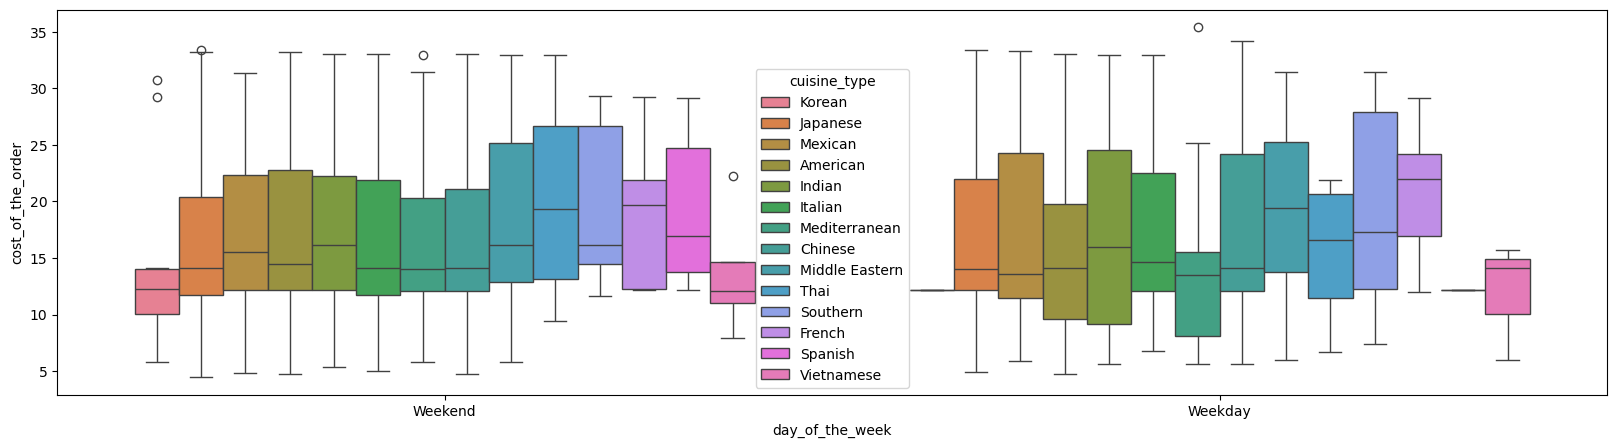

In [75]:
# Examining how delivery_time is affected by day of the week and type of food ordered
plt.figure(figsize=(20,5))
sns.boxplot(data=df,x='day_of_the_week',y='delivery_time',hue='cuisine_type')
print("-" * 100)
plt.show()

# Examining how food preparation time is affected by day of the week and type of food ordered
plt.figure(figsize=(20,5))
sns.boxplot(data=df,x='day_of_the_week',y='food_preparation_time',hue='cuisine_type')
print("-" * 100)

# Examining how food cost_of_the_order is affected by day of the week and type of food ordered
plt.figure(figsize=(20,5))
sns.boxplot(data=df,x='day_of_the_week',y='cost_of_the_order',hue='cuisine_type')
print("-" * 100)

# Food prep time and order cost are not affected by the day of the week, but delivery time appears to go down on weekends.
# Korean and Vietnamese restaurants tend to have the lowest food prep time, delivery time, and order costs, regardless of the day of the week.

restaurant_name
Shake Shack                  3579.530
The Meatball Shop            2145.210
Blue Ribbon Sushi            1903.950
Blue Ribbon Fried Chicken    1662.290
Parm                         1112.760
                               ...   
Market Table                    6.790
Wa Jeal                         6.740
Cipriani Le Specialita          5.920
Big Wong Restaurant _¤¾Ñ¼      5.920
Hunan Manor                     5.720
Name: cost_of_the_order, Length: 178, dtype: float64
----------------------------------------------------------------------------------------------------


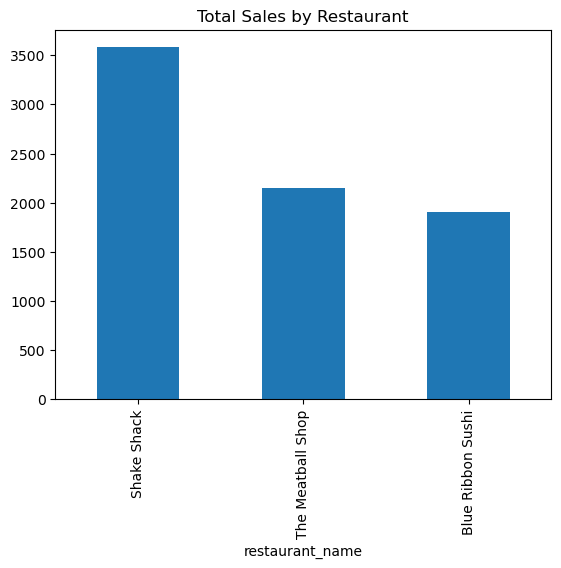

----------------------------------------------------------------------------------------------------
2.81 % of restaurants had sales over $1000.


In [77]:
# Total sum of sales by restaurant

# Make a list of the sum of all sales from each restaurant
df_sales = df.groupby(df['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending=False);
print(df_sales);
print("-" * 100)

# plot the total sales for the top 3 restaurants
df_sales_plot = df.groupby(df['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending=False).head(3).plot(kind='bar');
title = df_sales_plot.set_title('Total Sales by Restaurant');
plt.show()
print("-" * 100)


# pct of restaurants with sales over $1000
numb_rest_over_1k = df_sales[df_sales > 1000].value_counts().sum()
total_rest = df_sales.value_counts().sum()
pct_over_1k = round(numb_rest_over_1k / total_rest * 100, 2)
print(pct_over_1k, "% of restaurants had sales over $1000.")

# Only ~3% of restaurants have sales over $1000 and Shake Shack leads them at $3579.53

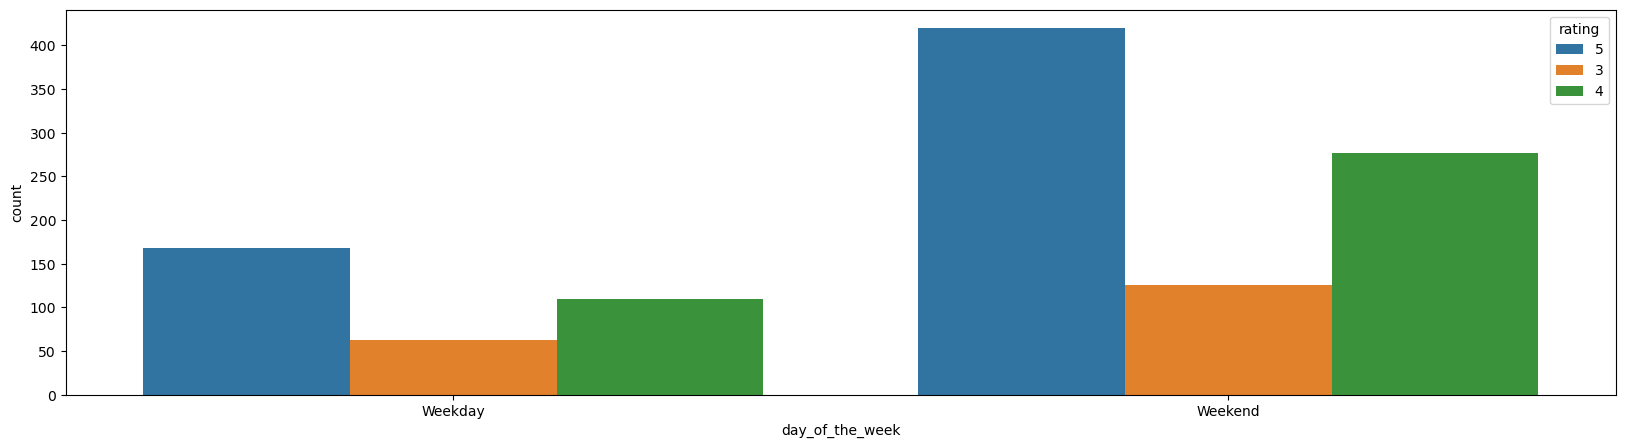

In [79]:
# Examining the number of orders by rating and day of the week
data_tmp = df[df['rating'] != 'Not given'].drop(columns=['restaurant_name','cuisine_type','order_id','customer_id'])

# plot the number of restaurant orders by rating and day of week
plt.figure(figsize=(20,5))
sns.countplot(data=data_tmp,x='day_of_the_week', hue = 'rating');

# Generally, the same proportion of 3,4, and 5 ratings are given on weekdays and weekends, but the total number of orders goes up on weekends.

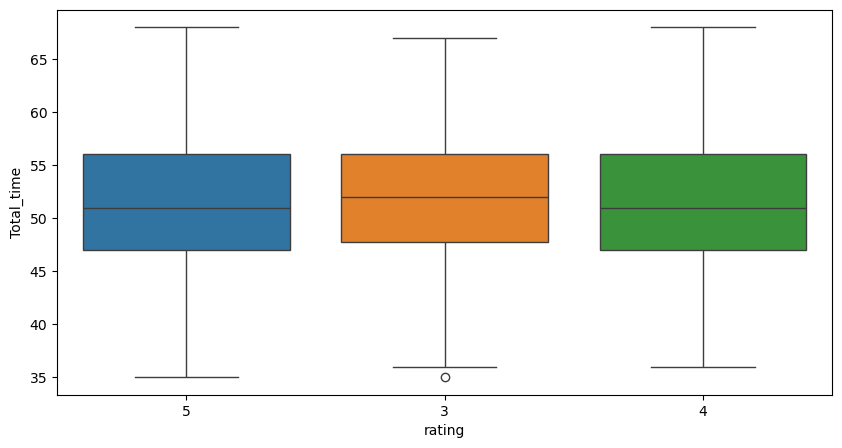

In [81]:
# Examining how total time differs across ratings
data_tmp['Total_time'] = data_tmp['food_preparation_time'] + data_tmp['delivery_time']

# Plot the total time taken to receive delivery by rating
plt.figure(figsize=(10,5))
sns.boxplot(data=data_tmp,x='rating',y='Total_time',hue='rating');
plt.show()

# The time between the order and receiving the food doesn't appear to affect the rating given.

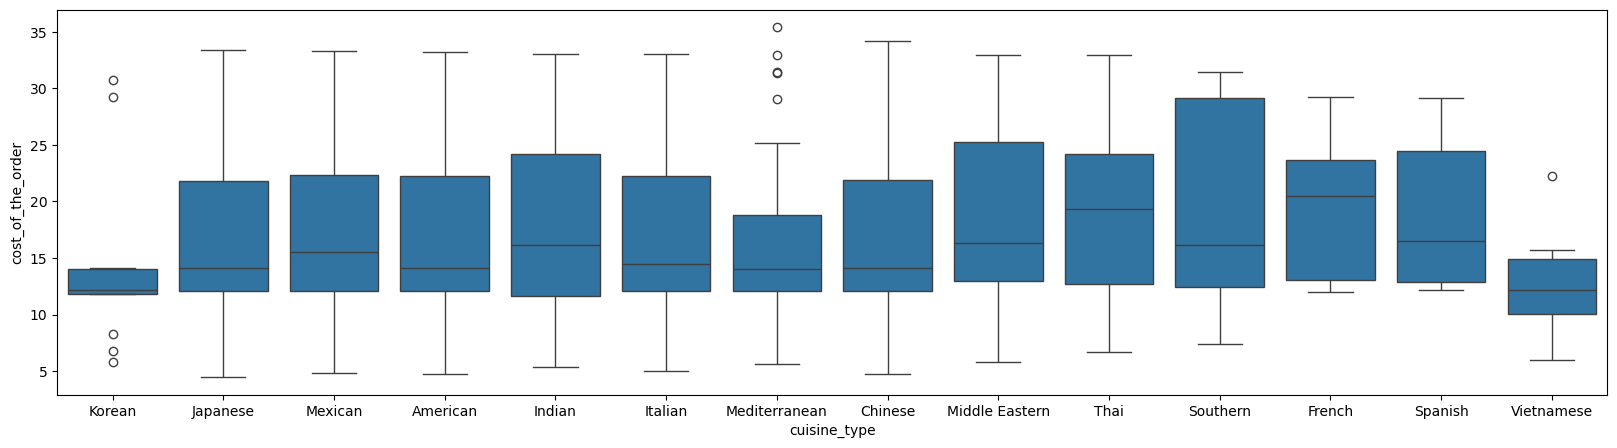

In [83]:
# Examining how the cost of an order differs across cuisine types
plt.figure(figsize=(20,5))
sns.boxplot(data=df,x='cuisine_type',y='cost_of_the_order');
plt.show()

# Costs appear to be lowest for Korean and Vietnamese orders give or take a few outliers.

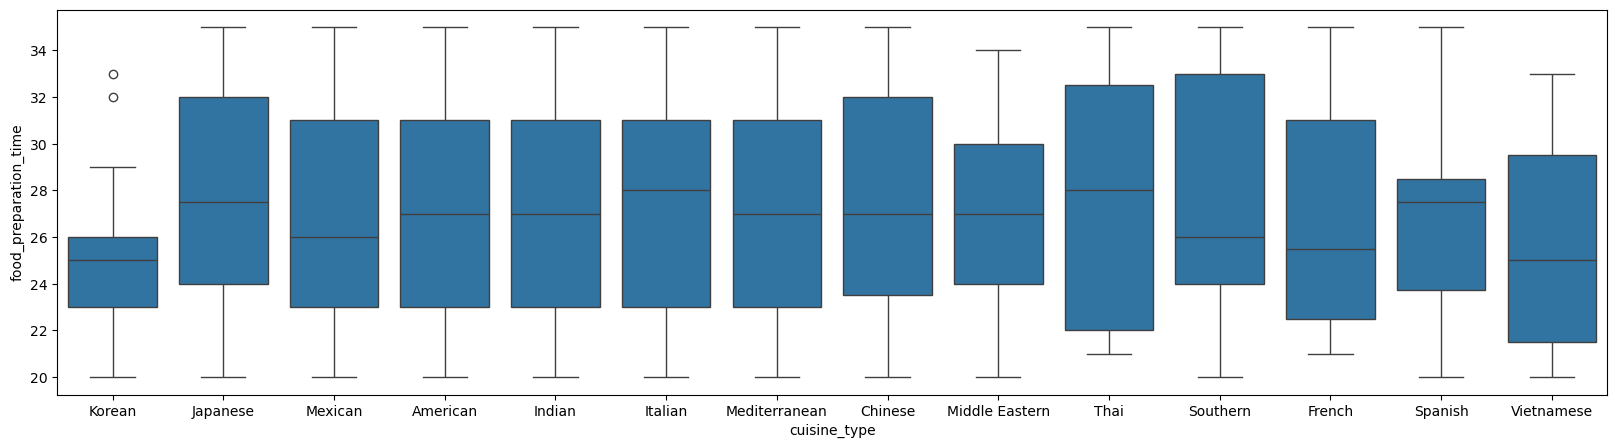

----------------------------------------------------------------------------------------------------
The fastest restaurants in terms of delivery time are:
Spanish is 26.92 minutes.
Thai is 27.32 minutes.
Vietnamese is 25.71 minutes.


In [85]:
# Examining how the preparation time differs across cuisine types
plt.figure(figsize=(20,5))
sns.boxplot(data=df,x='cuisine_type',y='food_preparation_time');
plt.show()
print("-" * 100)
fastest_restaurants = df.groupby(df['cuisine_type'])['food_preparation_time'].mean().tail(3)

# names of fastest restaurants
print("The fastest restaurants in terms of delivery time are:")
for i in fastest_restaurants.index:
  print(i, "is", fastest_restaurants[i].round(2), "minutes.")

# The fastest prep times are for Spanish, Thai, and Vietnamese restaurants.

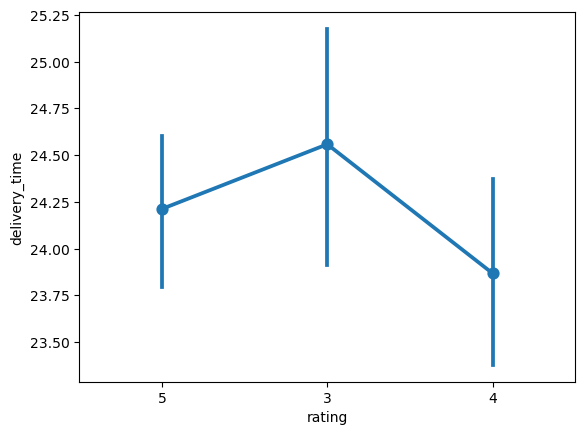

----------------------------------------------------------------------------------------------------
The delivery times for each rating are:
3 is 24.56 minutes.
4 is 23.87 minutes.
5 is 24.21 minutes.


In [87]:
# The relationship between rating and delivery_time
sns.pointplot(x = 'rating', y = 'delivery_time', data = data_tmp);
plt.show()
print("-" * 100)
ratings = data_tmp.groupby(data_tmp['rating'])['delivery_time'].mean().tail(3)

# delivery times by rating
print("The delivery times for each rating are:")
for i in ratings.index:
  print(i, "is", ratings[i].round(2), "minutes.")

# The lowest ratings are given for the orders with particularly slower delivery times (~24.50 minutes on average).
# However there is a wide amount of variation in the "3" ratings across delivery time.

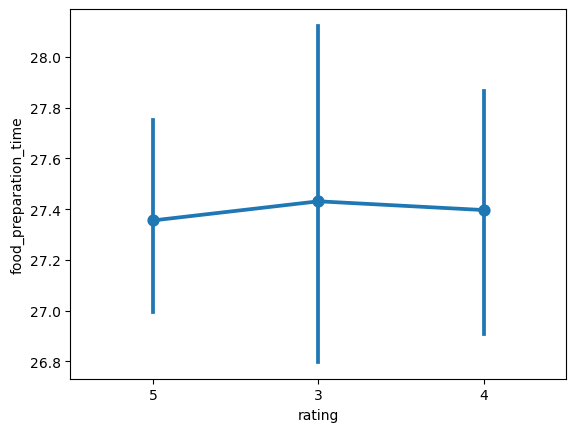

----------------------------------------------------------------------------------------------------
The food prep times for each rating are:
3 is 27.43 minutes.
4 is 27.4 minutes.
5 is 27.36 minutes.


In [89]:
# The relationship between rating and food_preparation time
sns.pointplot(x = 'rating', y = 'food_preparation_time', data = data_tmp);
plt.show()
print("-" * 100)
ratings_fp = data_tmp.groupby(data_tmp['rating'])['food_preparation_time'].mean().tail(3)

# delivery times by rating
print("The food prep times for each rating are:")
for i in ratings_fp.index:
  print(i, "is", ratings_fp[i].round(2), "minutes.")

# rating doesn't depend on food preparation time.

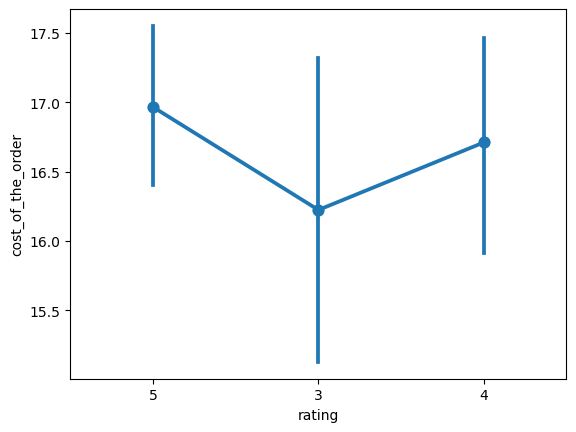

----------------------------------------------------------------------------------------------------
The food prep times for each rating are:
3 is 16.22 minutes.
4 is 16.71 minutes.
5 is 16.97 minutes.


In [91]:
# The relationship between rating and cost
sns.pointplot(x = 'rating', y = 'cost_of_the_order', data = data_tmp);
plt.show()
print("-" * 100)
ratings_cost = data_tmp.groupby(data_tmp['rating'])['cost_of_the_order'].mean().tail(3)

# delivery times by rating
print("The food prep times for each rating are:")
for i in ratings_cost.index:
  print(i, "is", ratings_cost[i].round(2), "minutes.")

# Orders with a low average cost (~$16.25) get low ratings.
# However, there is wide variation in the cost of orders for "3" ratings.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [93]:
# Write the code here

# Replace "Not given" values with nans and change the data type to float
df['new_rating'] = df['rating'].replace(['Not given'],np.nan)
df['new_rating'] = df['new_rating'].astype(float)

# restaurants with ratings higher than 50
df_ratings = df.groupby(df['restaurant_name'])['new_rating'].count().sort_values(ascending = False) > 50
ratings_rests = df_ratings[df_ratings == True].index
print("Restaurants with more than 50 ratings:")
for i in ratings_rests:
  print(i)

print("-" * 50)

# restaurants with average_ratings greater than 4
df_means = df.groupby(df['restaurant_name'])['new_rating'].mean().sort_values(ascending = False)
means_rests = df_means[df_means > 4].index
print("Restaurants with a mean rating of 4:")
for i in means_rests:
  print(i)

print("-" * 50)

# See below for restaurants satisfying both criteria.

Restaurants with more than 50 ratings:
Shake Shack
The Meatball Shop
Blue Ribbon Sushi
Blue Ribbon Fried Chicken
--------------------------------------------------
Restaurants with a mean rating of 4:
'wichcraft
Ravagh Persian Grill
Chola Eclectic Indian Cuisine
Chote Nawab
Junoon
Socarrat Paella Bar
DespaÌ±a
Dig Inn Seasonal Market
Saravanaa Bhavan
Donburi-ya
Dos Caminos
Dos Caminos Soho
Samurai Mama
El Parador Cafe
Prosperity Dumpling
Carmine's
Galli Restaurant
Grand Sichuan International
Philippe Chow
Olive Garden
Haru Gramercy Park
Moonstruck on Second
Mission Cantina
Hot Kitchen
Hunan Manor
Lantern Thai Kitchen
Klong
Kanoyama
Song Thai Restaurant & Bar
Cipriani Le Specialita
Vanessa's Dumpling House
Tortaria
da Umberto
67 Burger
Yama 49
Anjappar Chettinad
Asuka Sushi
Balade
Xe May Sandwich Shop
Vezzo Thin Crust Pizza
Bhatti Indian Grill
Big Daddy's
UVA Wine Bar & Restaurant
Kambi Ramen House
Cafe de La Esquina
Taro Sushi
Bukhara Grill
Sushi Samba
Otto Enoteca Pizzeria
Boqueria
Luc

In [95]:
# Find overlapping restaurants betweent the two lists
overlapping_rests = ratings_rests.intersection(means_rests)
print("Restaurants with more than 50 ratings and a mean rating of 4:")
for i in overlapping_rests:
  print(i)

  # Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken are the only restaurants with more than 50 ratings that average above 4.

Restaurants with more than 50 ratings and a mean rating of 4:
Shake Shack
The Meatball Shop
Blue Ribbon Sushi
Blue Ribbon Fried Chicken


#### Observations:


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [97]:
# Find net revenue
net_revenue = 0
for i in df['cost_of_the_order']:
  if i > 20:
    net_revenue += i*0.25
  elif i > 5:
    net_revenue += i*0.15

print("The net revenue generated by the company across all orders is $", round(net_revenue,2), ".")

# The company made a net revenue of $6166.3

The net revenue generated by the company across all orders is $ 6166.3 .


#### Observations:


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [99]:
# Total time to deliver food
df['Total_time'] = df['food_preparation_time'] + df['delivery_time']

# calculate number of slower deliveries (> 60 minutes total time)
slow_deliveries = df[df['Total_time'] > 60].value_counts().sum()

# calculate number of deliveries
total_deliveries = df['Total_time'].value_counts().sum()

# calculate percentage of deliveries that take longer than 60 minutes
pct_slow = round(slow_deliveries / total_deliveries * 100, 2)
print(pct_slow, "% of orders take more than 60 minutes to get delivered.")

# Very few orders (6.27%) exceed 60 minutes from time of order to food arrival.

6.27 % of orders take more than 60 minutes to get delivered.


#### Observations:


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [101]:
# Delivery time by day of the week

# Group the day of the week and list the mean delivery times for each
by_week = df.groupby(df['day_of_the_week'])['delivery_time'].mean()
print("The mean delivery time on the weekdays is", round(by_week.iloc[0]), "minutes.")
print("The mean delivery time on the weekends is", round(by_week.iloc[1]), "minutes.")

# What is the difference in average delivery time between weekdays and weekends
diff_week = by_week.iloc[0] - by_week.iloc[1]
print("The difference in mean delivery time between weekdays and weekends is", round(diff_week), "minutes in favor of weekdays.")

# Delivery times go down on weekends by about 6 minutes

The mean delivery time on the weekdays is 28 minutes.
The mean delivery time on the weekends is 22 minutes.
The difference in mean delivery time between weekdays and weekends is 6 minutes in favor of weekdays.


#### Observations:


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
#### **Univariate**
###### 1. Only a few restaurants have over 100 orders.
###### 2. American and Japenese restaurants are most commonly ordered.
###### 3. Most orders are between 10-15 dollars, although the average is around $16.

###### 4. Mean food preparation time is about 27 minutes with a standard deviation of  4.5. While a few food preparation times (e.g., 20,25) are more common, overall it seems that all delivery times are equally likely to occur. It also seems that food preparation time does not affect ratings (see below).

##### 5. The mean delivery time is 24 minutes with a standard deviation of about 5.

#### **Multivariate**

###### 1. There does not appear to be any association between:
###### Food prep time and cost of order
###### Delivery time and cost of order
###### Delivery time and food prep time

###### 2. Food prep time and order cost are not strongly affected by the day of the week.

###### 3. Korean and Vietnamese restaurants tend to have the lowest food prep time, delivery time, and order costs, regardless of the day of the week.

###### 4. Only ~3% of restaurants have sales over 1000 dollars and Shake Shack leads them at $3579.53.

###### 5. Generally, the same proportion of 3,4, and 5 ratings are given on weekdays and weekends.

###### 6. The time between the order and receiving the food doesn't appear to affect the rating given.

###### 7. Costs appear to be lowest for Korean and Vietnamese orders give or take a few outliers.

###### 8. The fastest prep times are for Spanish, Thai, and Vietnamese restaurants.

###### 9.The lowest ratings are given for the orders with particularly slower delivery times (~24.50 minutes on average). However there is a wide amount of variation in the "3" ratings across delivery time.

###### 10. Ratings don't appear to depend on food preparation time.

###### 11. Orders with a low average cost (~$16.25) get low ratings. However, there is wide variation in the cost of orders for "3" ratings.

###### 12. Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken are the only restaurants with more than 50 ratings that average above 4.

###### 13. The company made a net revenue of $6166.3.

###### 14. Very few orders (6.27%) exceed 60 minutes from time of order to food arrival.

###### 15. Delivery times go down and order costs go up on weekends.

### Recommendations:

The company is likely to care about the cost of orders and customer ratings, since both help increase profits. Here are several recommendatiuons to maximize both.


1. The most number of orders come from American and Japanese food restaurants. Locating and partnering with businesses that sell these types of food may yield more profit.
2. There appears to be a delivery time threshold where ratings drop to the "3" level. Incentivizing lower delivery times for its slower carriers may help to decrease the number of lower ratings amongst apps users.
3. Since delivery times are higher on weekdays and delivery time may be related to lower ratings, incentivizing carriers on weekdays may drive up ratings amongst app users.
4. Lower food costs are likely associated with less food. Since there is some evidence that lower overall order costs bring down ratings, the company can distribute vouchers to increase the total cost of orders. This may increase rating scores amongst app users. Targeting users with particularly lower order costs may be particularly helpful.
5. Korean and Vietnamese restaurants are very good at reducing the wait between the order and food arrival, but have relatively low order costs. The company may think about helping these restaurants increase their sales. One strategy is for the restaurants to offer increasing discounts based on the amount of food ordered (e.g., 10% discount on orders of 20 dollars or more, 20% discount on orders of 30 dp;;ars or more, 30% discount on orders 50 dollars or more).

---